In [1]:
print("VS Code Notebook is ready!")

VS Code Notebook is ready!


In [1]:
import sys
print(sys.executable)

c:\Users\GowthamReddy\OneDrive\Documents\Study_project\venv\Scripts\python.exe


In [4]:
import sys
print(sys.executable)

c:\Users\Nallapa Reddy\AppData\Local\Programs\Python\Python314\python.exe


In [2]:
import pandas as pd
print("Pandas is working!")

Pandas is working!


In [3]:
df = pd.read_csv("study_behavior_dataset.csv")
df.head()

,Student_ID,Study_Time_Hours,Distraction_Level,Study_Pattern,Attention_Span_Minutes,Past_Score_Percentage,Quiz_Score_Percentage
0,1,3.62,Medium,Morning,82,54,69.44
1,2,7.66,Low,Afternoon,36,55,78.92
2,3,6.12,Low,Morning,52,75,97.44
3,4,5.19,High,Morning,48,53,63.18
4,5,2.09,Medium,Afternoon,32,68,75.38


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

Matplotlib is building the font cache; this may take a moment.


In [5]:
df = pd.read_csv("study_behavior_dataset.csv")
df.head()

,Student_ID,Study_Time_Hours,Distraction_Level,Study_Pattern,Attention_Span_Minutes,Past_Score_Percentage,Quiz_Score_Percentage
0,1,3.62,Medium,Morning,82,54,69.44
1,2,7.66,Low,Afternoon,36,55,78.92
2,3,6.12,Low,Morning,52,75,97.44
3,4,5.19,High,Morning,48,53,63.18
4,5,2.09,Medium,Afternoon,32,68,75.38


In [6]:
# Shape of dataset
df.shape

(200, 7)

In [7]:
df.columns

Index(['Student_ID', 'Study_Time_Hours', 'Distraction_Level', 'Study_Pattern',
       'Attention_Span_Minutes', 'Past_Score_Percentage',
       'Quiz_Score_Percentage'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Student_ID              200 non-null    int64  
 1   Study_Time_Hours        200 non-null    float64
 2   Distraction_Level       200 non-null    str    
 3   Study_Pattern           200 non-null    str    
 4   Attention_Span_Minutes  200 non-null    int64  
 5   Past_Score_Percentage   200 non-null    int64  
 6   Quiz_Score_Percentage   200 non-null    float64
dtypes: float64(2), int64(3), str(2)
memory usage: 11.1 KB


In [9]:
# Statistical summary
df.describe()

,Student_ID,Study_Time_Hours,Attention_Span_Minutes,Past_Score_Percentage,Quiz_Score_Percentage
count,200.000000,200.000000,200.000000,200.00000,200.000000
mean,100.500000,4.388450,54.390000,70.19000,83.652700
std,57.879185,2.064389,21.257878,12.26401,12.638461
min,1.000000,1.040000,20.000000,50.00000,53.820000
25%,50.750000,2.600000,36.000000,59.00000,72.830000
50%,100.500000,4.465000,53.000000,71.50000,85.520000
75%,150.250000,6.300000,73.250000,82.00000,94.985000
max,200.000000,7.910000,89.000000,89.00000,100.000000


In [10]:
df.isnull().sum()

Student_ID                0
Study_Time_Hours          0
Distraction_Level         0
Study_Pattern             0
Attention_Span_Minutes    0
Past_Score_Percentage     0
Quiz_Score_Percentage     0
dtype: int64

In [11]:
df.isnull().sum()

Student_ID                0
Study_Time_Hours          0
Distraction_Level         0
Study_Pattern             0
Attention_Span_Minutes    0
Past_Score_Percentage     0
Quiz_Score_Percentage     0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.drop_duplicates()

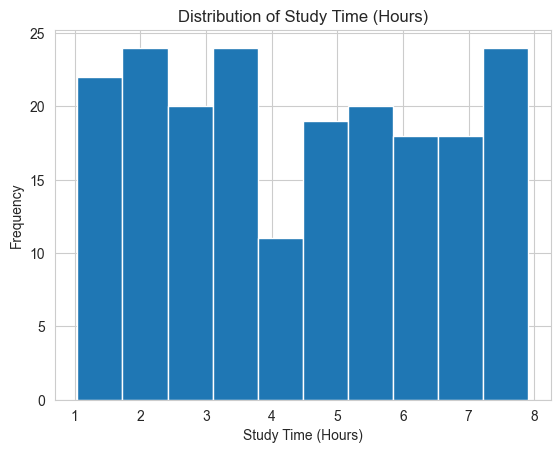

In [7]:
plt.figure()
plt.hist(df['Study_Time_Hours'], bins=10)
plt.title("Distribution of Study Time (Hours)")
plt.xlabel("Study Time (Hours)")
plt.ylabel("Frequency")
plt.show()

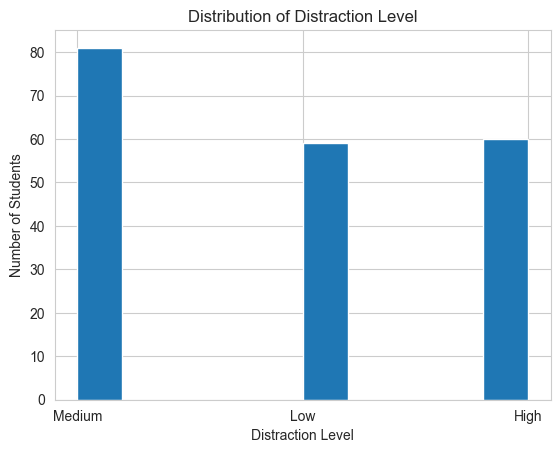

In [17]:
plt.figure()
plt.hist(df['Distraction_Level'], bins=10)
plt.title("Distribution of Distraction Level")
plt.xlabel("Distraction Level")
plt.ylabel("Number of Students")
plt.show()

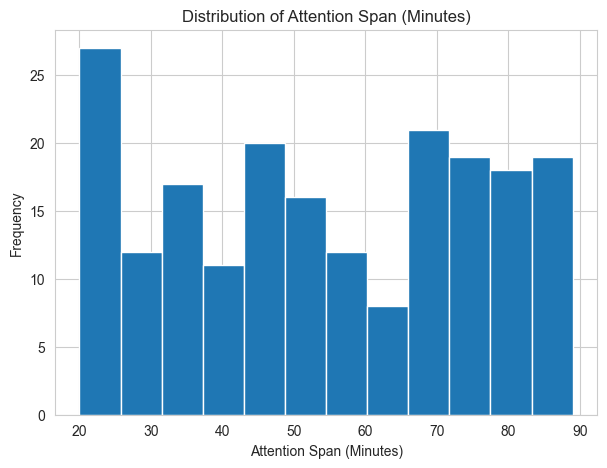

In [20]:
plt.figure(figsize=(7,5))
plt.hist(df['Attention_Span_Minutes'], bins=12)
plt.title("Distribution of Attention Span (Minutes)")
plt.xlabel("Attention Span (Minutes)")
plt.ylabel("Frequency")
plt.show()

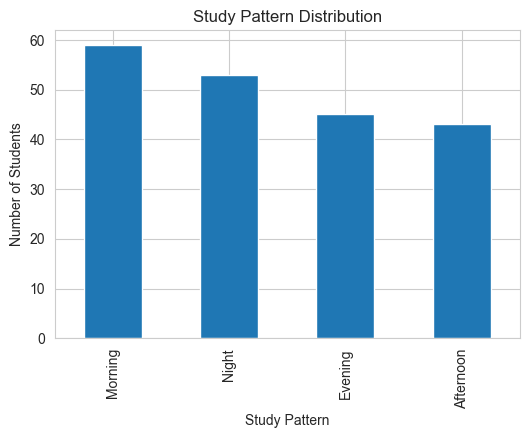

In [21]:
plt.figure(figsize=(6,4))
df['Study_Pattern'].value_counts().plot(kind='bar')
plt.title("Study Pattern Distribution")
plt.xlabel("Study Pattern")
plt.ylabel("Number of Students")
plt.show()

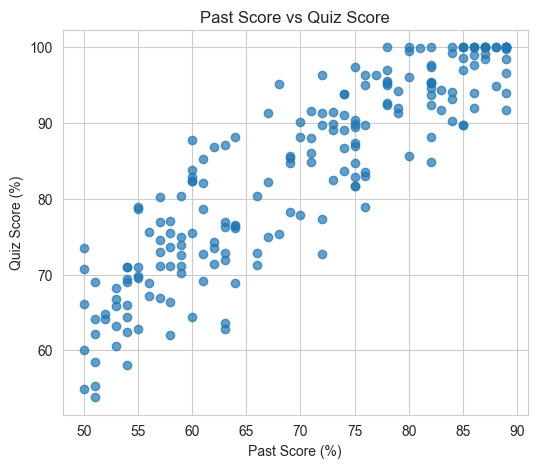

In [22]:
plt.figure(figsize=(6,5))
plt.scatter(df['Past_Score_Percentage'], df['Quiz_Score_Percentage'], alpha=0.7)
plt.title("Past Score vs Quiz Score")
plt.xlabel("Past Score (%)")
plt.ylabel("Quiz Score (%)")
plt.show()

<Figure size 600x500 with 0 Axes>

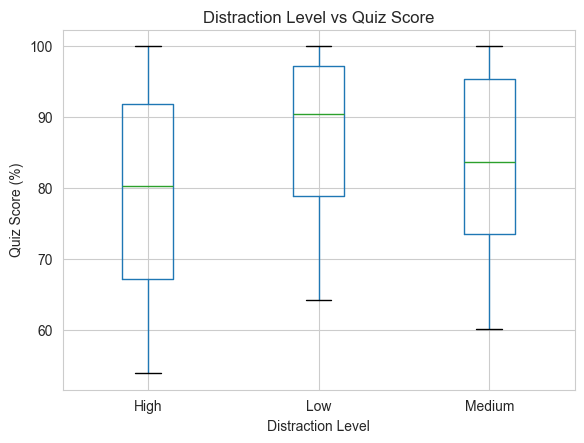

In [24]:
plt.figure(figsize=(6,5))
df.boxplot(column='Quiz_Score_Percentage', by='Distraction_Level')
plt.title("Distraction Level vs Quiz Score")
plt.suptitle("")
plt.xlabel("Distraction Level")
plt.ylabel("Quiz Score (%)")
plt.show()

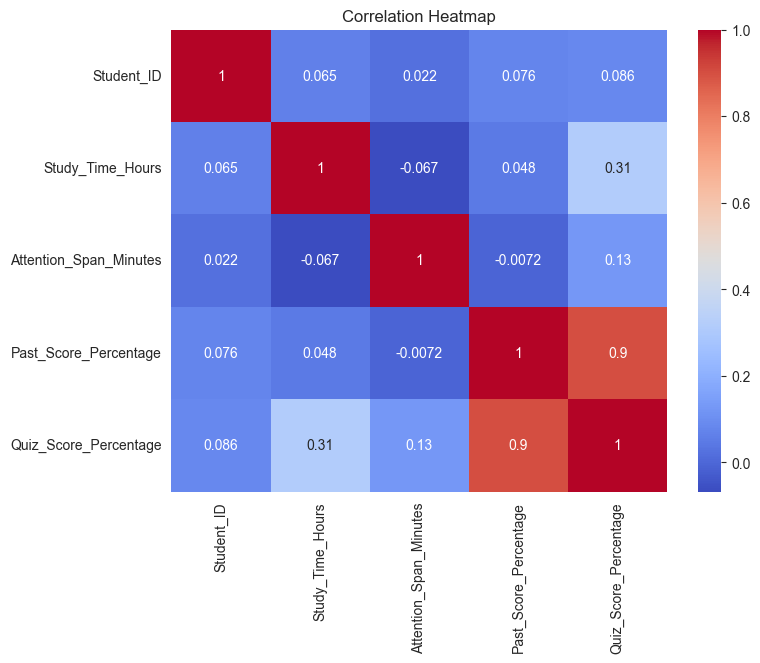

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

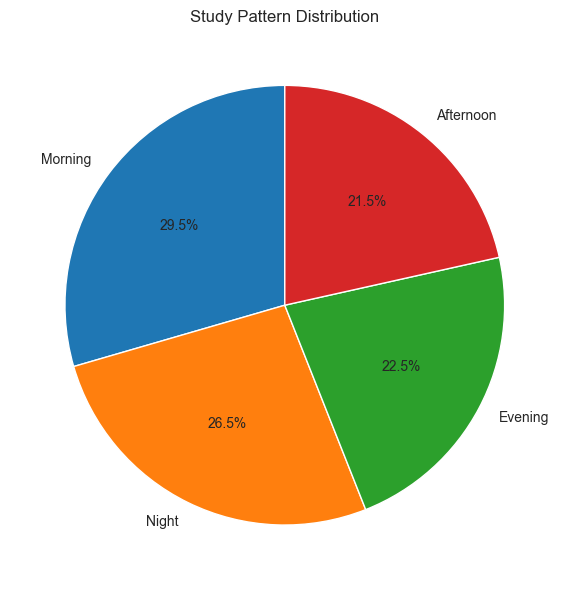

In [40]:
plt.figure(figsize=(6,6))

study_counts = df['Study_Pattern'].value_counts()

plt.pie(study_counts,
        labels=study_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Study Pattern Distribution")

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd

df = pd.read_csv("study_behavior_dataset.csv")

In [2]:
X = df[["Study_Time", "Quiz_Score"]]

KeyError: "None of [Index(['Study_Time', 'Quiz_Score'], dtype='str')] are in the [columns]"

In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)

ModuleNotFoundError: No module named 'sklearn'

In [4]:
print(df.columns)

Index(['Student_ID', 'Study_Time_Hours', 'Distraction_Level', 'Study_Pattern',
       'Attention_Span_Minutes', 'Past_Score_Percentage',
       'Quiz_Score_Percentage'],
      dtype='str')


In [5]:
X = df[['Study_Time_Hours', 'Quiz_Score_Percentage']]

In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

ModuleNotFoundError: No module named 'sklearn'

In [8]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

ModuleNotFoundError: No module named 'sklearn'

In [9]:
!pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl (36.5 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
Successfully installed scikit-learn

SyntaxError: invalid syntax (3001266448.py, line 1)